<a href="https://colab.research.google.com/github/catherine-rina/PROJET-Energisight/blob/main/SiteEnergyUse(kBtu).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import missingno as msno
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Évaluation
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv('/content/2016_Building_Energy_Benchmarking.csv')
data.head ()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
df = data.copy()

In [ ]:
df.shape

(3376, 46)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [ ]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [ ]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [ ]:

df['SiteEnergyUse(kBtu)'].describe()

,SiteEnergyUse(kBtu)
count,3.371000e+03
mean,5.403667e+06
std,2.161063e+07
min,0.000000e+00
25%,9.251286e+05
50%,1.803753e+06
75%,4.222455e+06
max,8.739237e+08


In [ ]:
df.isnull().mean()

,0
OSEBuildingID,0.000000
DataYear,0.000000
BuildingType,0.000000
PrimaryPropertyType,0.000000
PropertyName,0.000000
Address,0.000000
City,0.000000
State,0.000000
ZipCode,0.004739
TaxParcelIdentificationNumber,0.000000


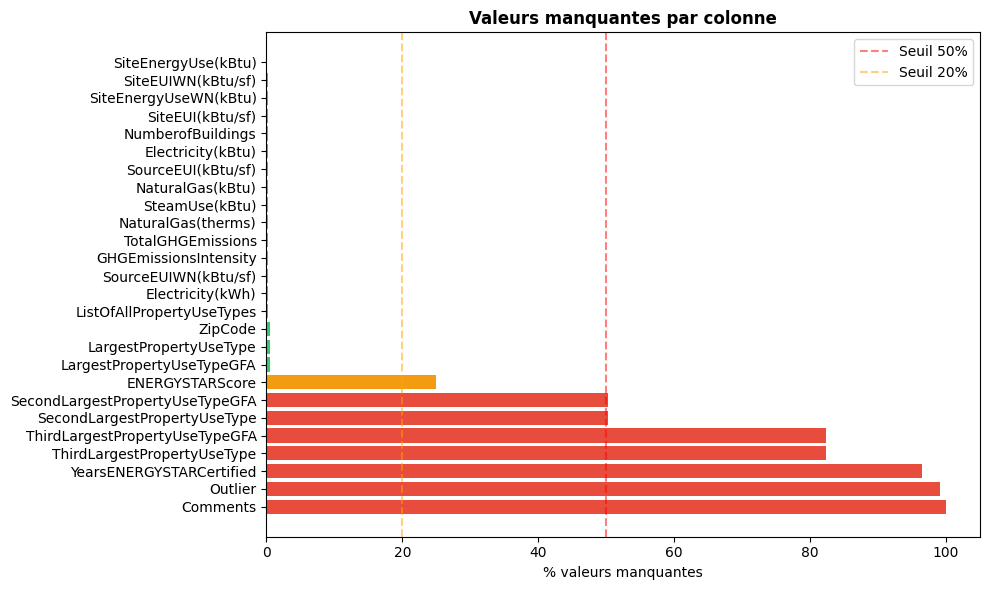

                        Colonne  % manquant
                       Comments  100.000000
                        Outlier   99.052133
       YearsENERGYSTARCertified   96.475118
    ThirdLargestPropertyUseType   82.345972
 ThirdLargestPropertyUseTypeGFA   82.345972
   SecondLargestPropertyUseType   50.266588
SecondLargestPropertyUseTypeGFA   50.266588
                ENERGYSTARScore   24.970379
      LargestPropertyUseTypeGFA    0.592417
         LargestPropertyUseType    0.592417
                        ZipCode    0.473934
      ListOfAllPropertyUseTypes    0.266588
               Electricity(kWh)    0.266588
           SourceEUIWN(kBtu/sf)    0.266588
          GHGEmissionsIntensity    0.266588
              TotalGHGEmissions    0.266588
             NaturalGas(therms)    0.266588
                 SteamUse(kBtu)    0.266588
               NaturalGas(kBtu)    0.266588
             SourceEUI(kBtu/sf)    0.266588
              Electricity(kBtu)    0.266588
              NumberofBuildings 

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Colonne', '% manquant']
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_df['Colonne'], missing_df['% manquant'],
               color=['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71'
                      for v in missing_df['% manquant']])
ax.set_xlabel('% valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='Seuil 50%')
ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='Seuil 20%')
ax.legend()
plt.tight_layout()
plt.show()

print(missing_df.to_string(index=False))



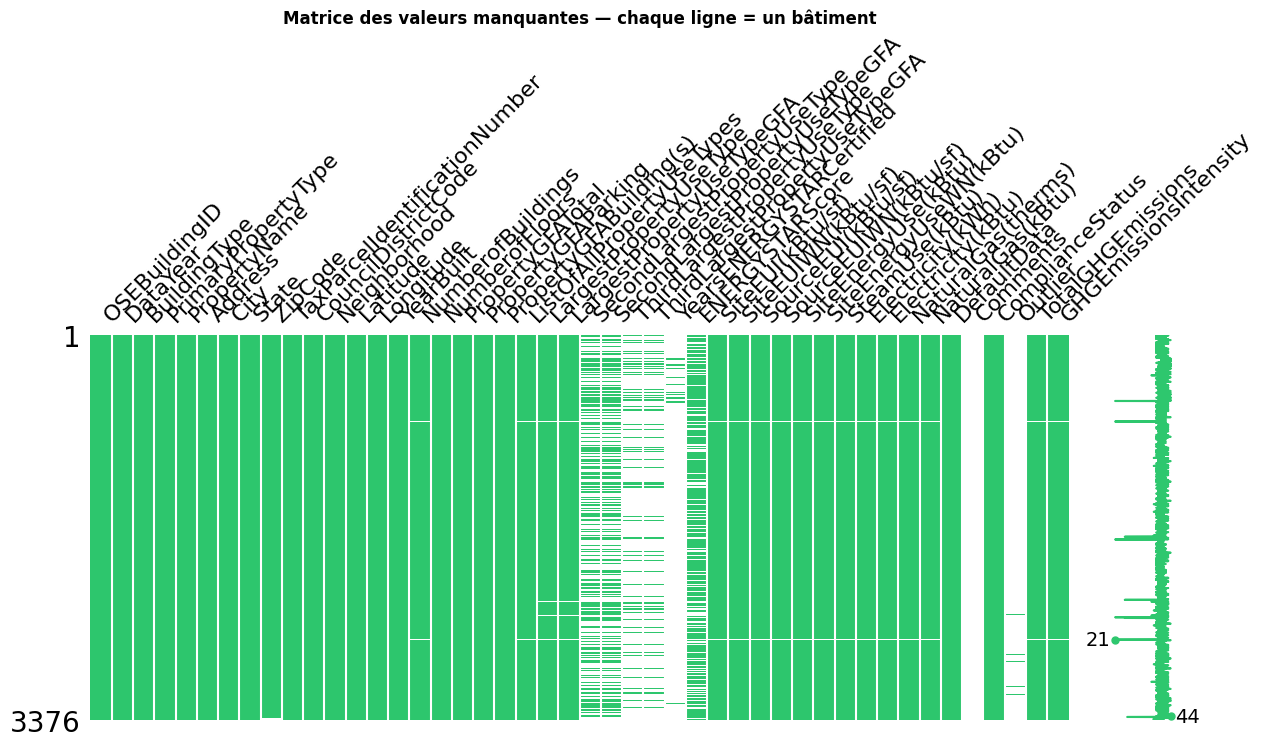

In [ ]:
msno.matrix(df, figsize=(14, 5), color=(0.18, 0.78, 0.43))
plt.title('Matrice des valeurs manquantes — chaque ligne = un bâtiment', fontweight='bold')
plt.show()

In [ ]:
df_labeled = df.dropna(subset=TARGETS).copy()
print(f'Dataset supervisé (cibles connues) : {df_labeled.shape[0]:,} lignes (sur {df.shape[0]:,} initiales)')
print(f'Lignes sans cibles (à prédire) : {df.shape[0] - df_labeled.shape[0]}')

Dataset supervisé (cibles connues) : 3,367 lignes (sur 3,376 initiales)
Lignes sans cibles (à prédire) : 9


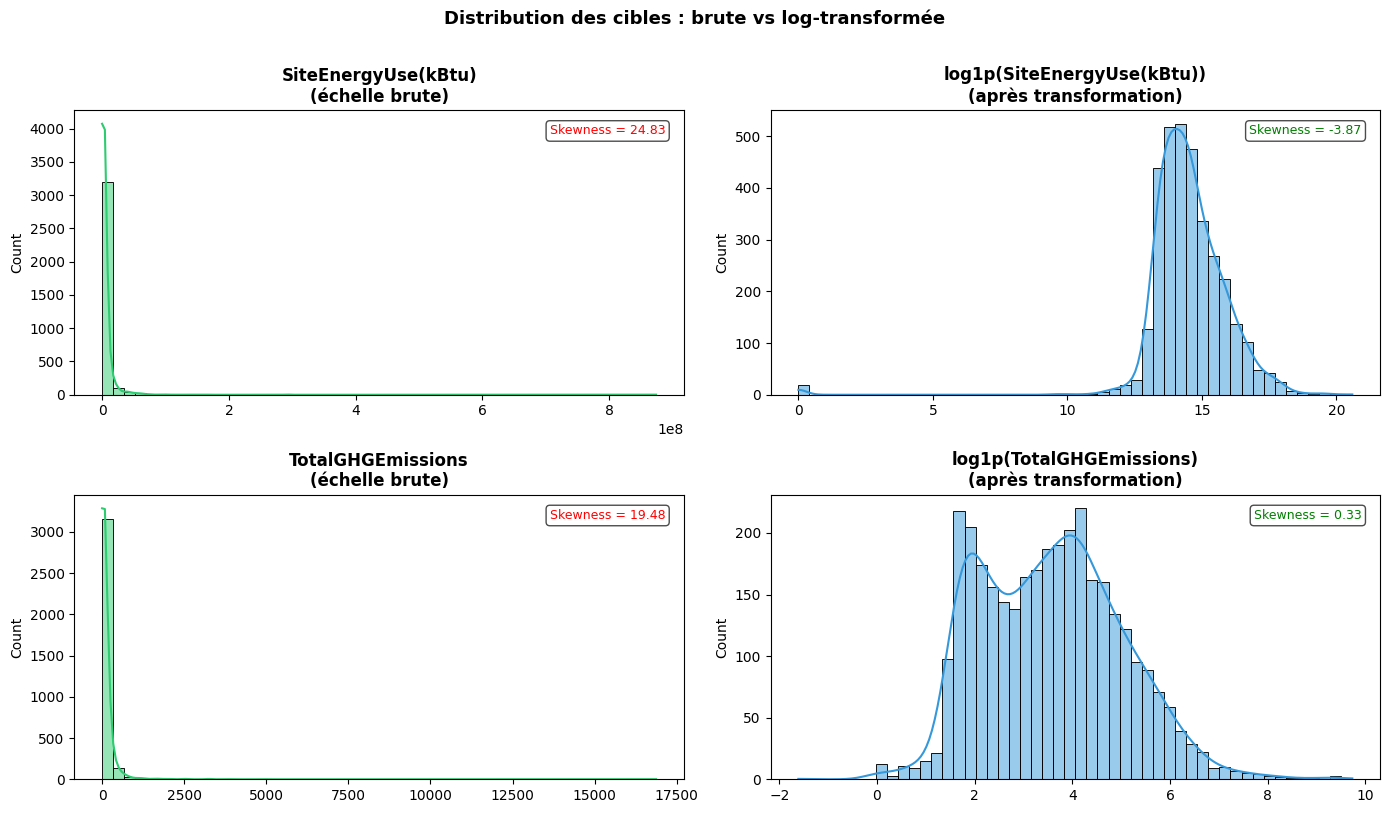

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, target in enumerate(TARGETS):
    data = df_labeled[target].dropna()
    data_log = np.log1p(data)

    # Distribution brute
    ax = axes[i, 0]
    sns.histplot(data, kde=True, ax=ax, color='#2dcc70', bins=50)
    ax.set_title(f'{target}\n(échelle brute)', fontweight='bold')
    ax.set_xlabel('')
    skew_val = data.skew()
    ax.annotate(f'Skewness = {skew_val:.2f}', xy=(0.97, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=9, color='red',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Distribution log-transformée
    ax2 = axes[i, 1]
    sns.histplot(data_log, kde=True, ax=ax2, color='#3498db', bins=50)
    ax2.set_title(f'log1p({target})\n(après transformation)', fontweight='bold')
    ax2.set_xlabel('')
    skew_log = data_log.skew()
    ax2.annotate(f'Skewness = {skew_log:.2f}', xy=(0.97, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=9, color='green',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Distribution des cibles : brute vs log-transformée', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

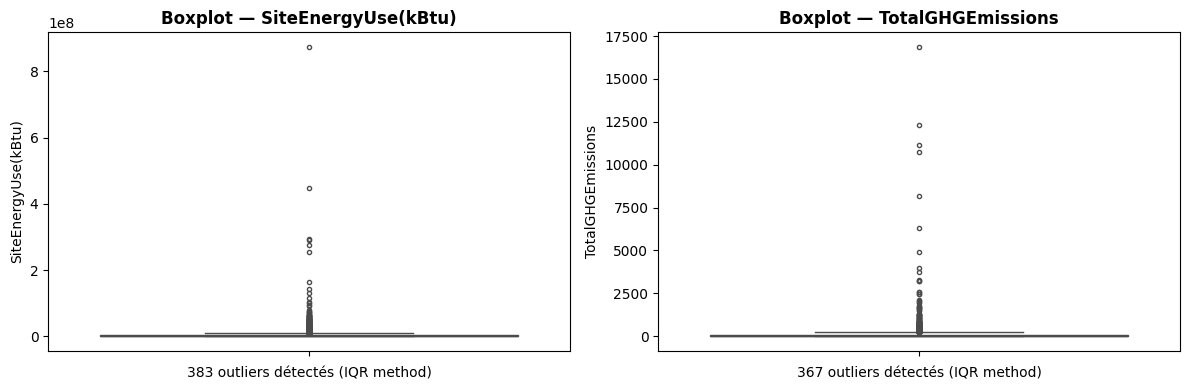

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, target in enumerate(TARGETS):
    sns.boxplot(y=df_labeled[target], ax=axes[i], color='#2dcc70', flierprops=dict(marker='o', markersize=3))
    axes[i].set_title(f'Boxplot — {target}', fontweight='bold')
    q1, q3 = df_labeled[target].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df_labeled[(df_labeled[target] < q1 - 1.5*iqr) | (df_labeled[target] > q3 + 1.5*iqr)]
    axes[i].set_xlabel(f'{len(outliers)} outliers détectés (IQR method)')
plt.tight_layout()
plt.show()

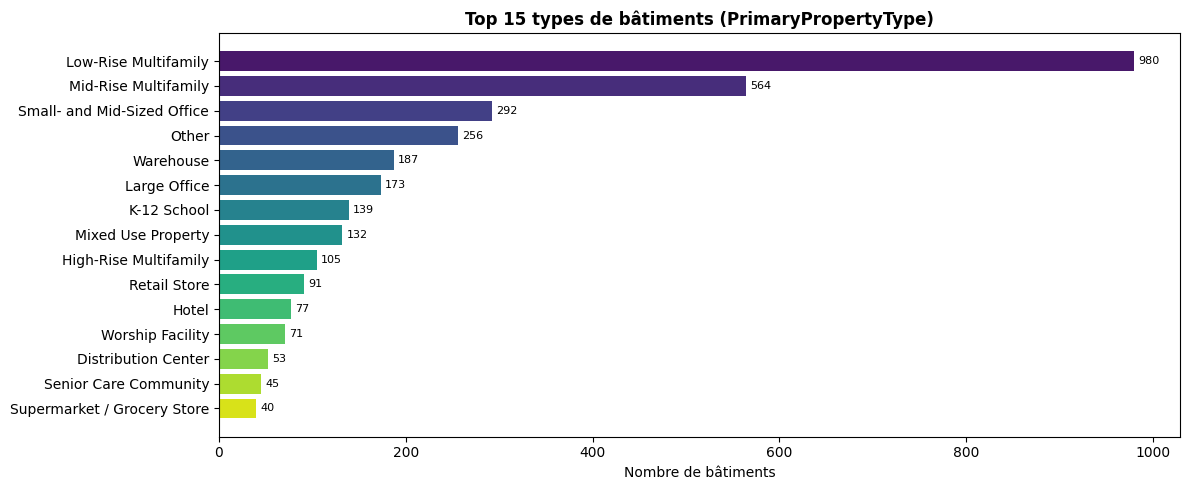

In [ ]:
top_types = df_labeled['PrimaryPropertyType'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_types.index[::-1], top_types.values[::-1],
               color=sns.color_palette('viridis', len(top_types))[::-1])
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Top 15 types de bâtiments (PrimaryPropertyType)', fontweight='bold')
ax.set_xlabel('Nombre de bâtiments')
plt.tight_layout()
plt.show()

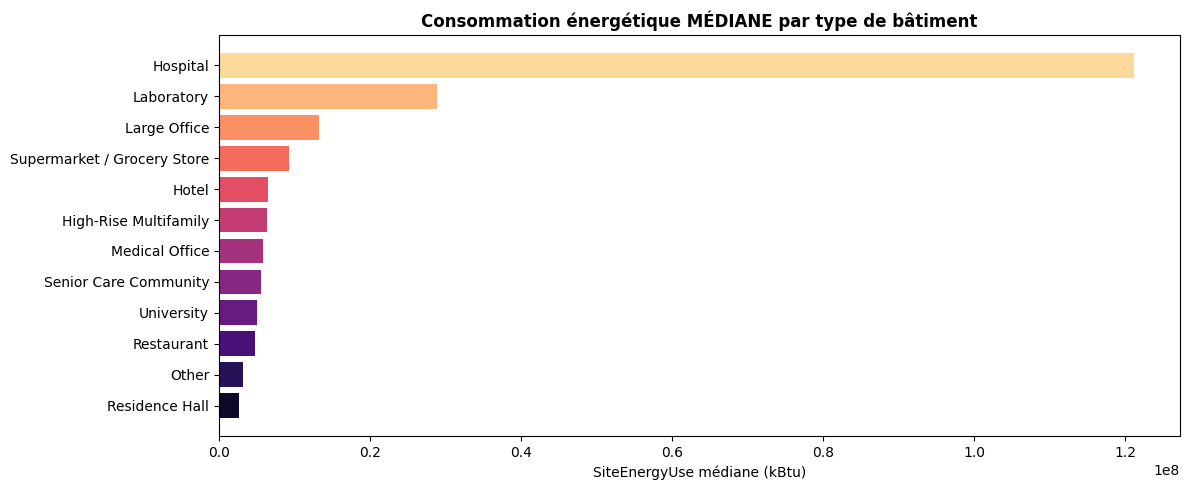

In [ ]:
median_energy = (df_labeled.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)']
                 .median().sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(median_energy.index[::-1], median_energy.values[::-1],
               color=sns.color_palette('magma_r', len(median_energy))[::-1])
ax.set_title('Consommation énergétique MÉDIANE par type de bâtiment', fontweight='bold')
ax.set_xlabel('SiteEnergyUse médiane (kBtu)')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


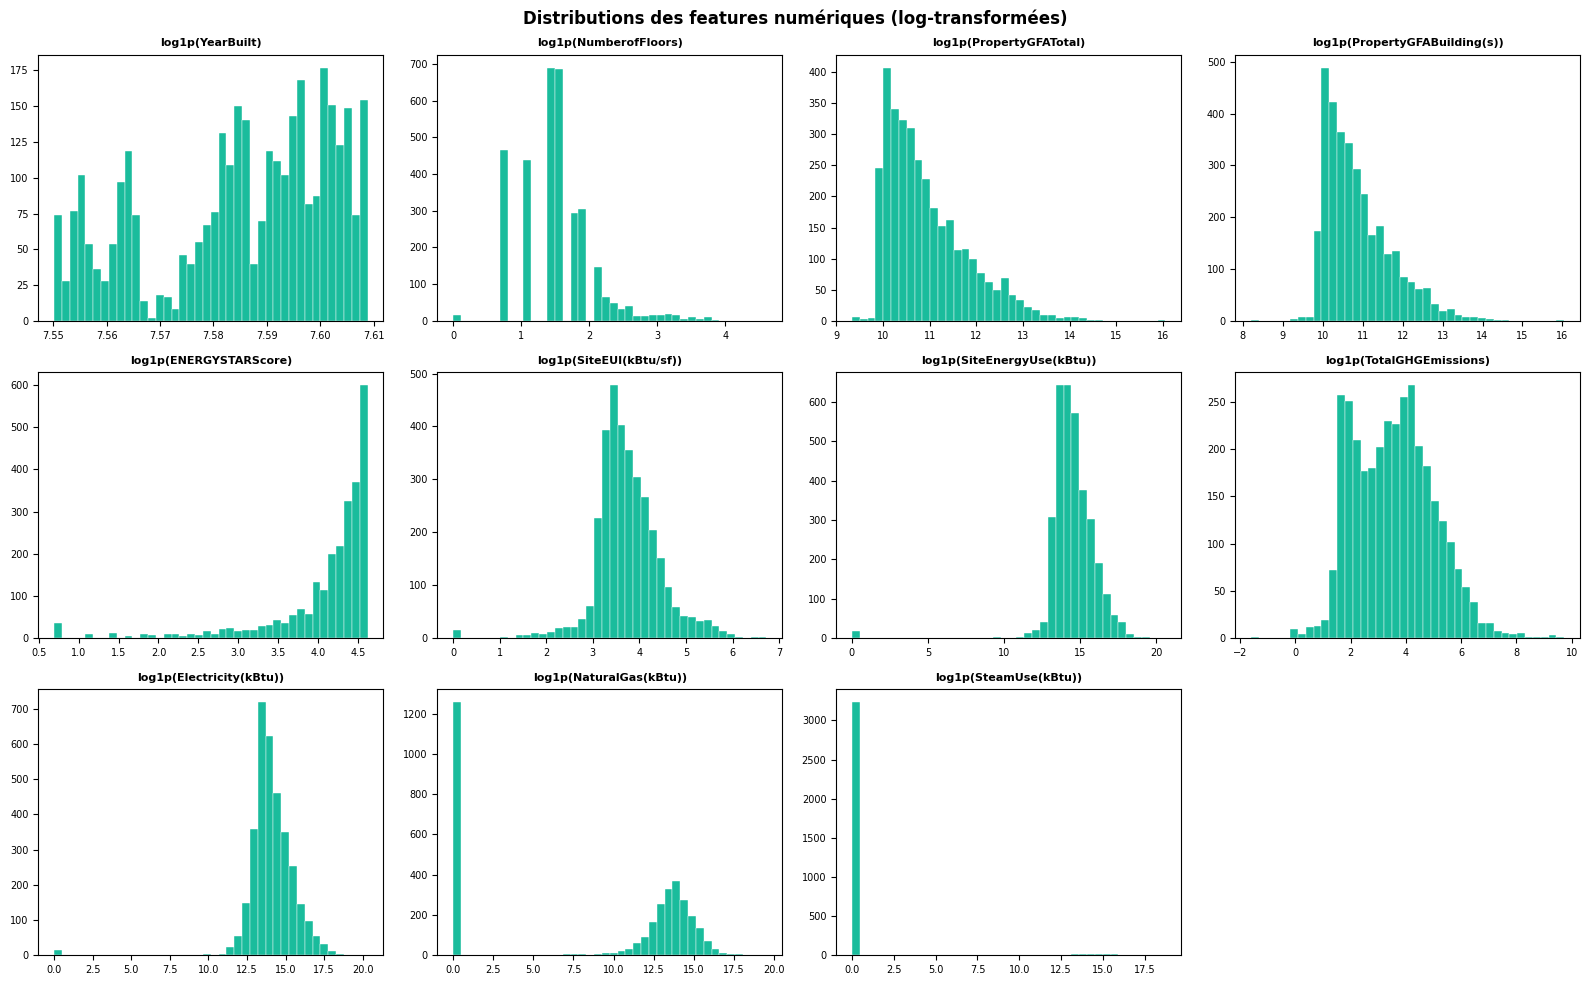

In [ ]:
NUM_FEATURES = [
    'YearBuilt', 'NumberofFloors', 'PropertyGFATotal',
    'PropertyGFABuilding(s)', 'ENERGYSTARScore',
    'SiteEUI(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'TotalGHGEmissions',
    'Electricity(kBtu)', 'NaturalGas(kBtu)', 'SteamUse(kBtu)'
]

df_num = df_labeled[NUM_FEATURES].copy()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    data = df_num[col].dropna()
    axes[i].hist(np.log1p(data), bins=40, color='#1abc9c', edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'log1p({col})', fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)

# Cacher les axes vides
for j in range(len(NUM_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des features numériques (log-transformées)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

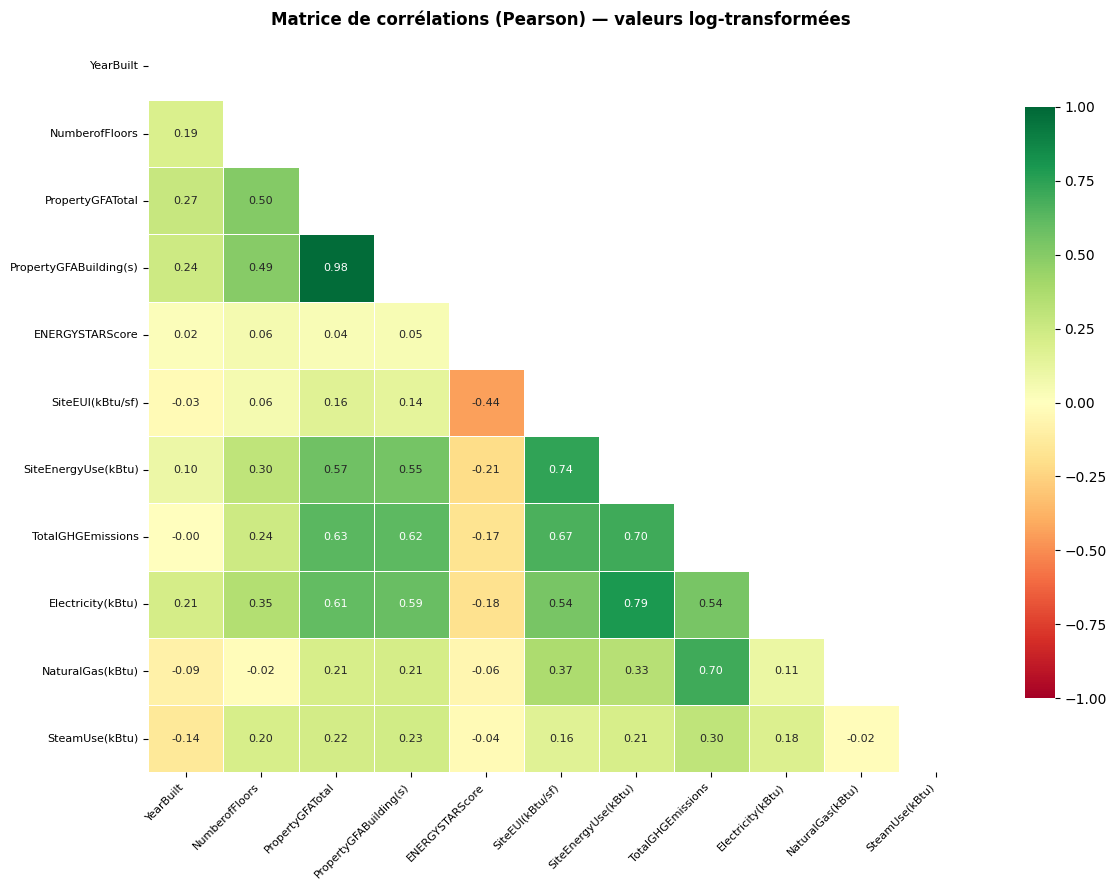

In [ ]:
df_log = np.log1p(df_num.clip(lower=0))
corr = df_log.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # triangle supérieur masqué

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélations (Pearson) — valeurs log-transformées',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
print('=== Corrélations avec SiteEnergyUse(kBtu) ===')
print(corr['SiteEnergyUse(kBtu)'].sort_values(ascending=False).to_string())

print('\n=== Corrélations avec TotalGHGEmissions ===')
print(corr['TotalGHGEmissions'].sort_values(ascending=False).to_string())

=== Corrélations avec SiteEnergyUse(kBtu) ===
SiteEnergyUse(kBtu)       1.000000
Electricity(kBtu)         0.791340
SiteEUI(kBtu/sf)          0.737152
TotalGHGEmissions         0.699022
PropertyGFATotal          0.568627
PropertyGFABuilding(s)    0.553133
NaturalGas(kBtu)          0.328857
NumberofFloors            0.303586
SteamUse(kBtu)            0.206641
YearBuilt                 0.099266
ENERGYSTARScore          -0.208897

=== Corrélations avec TotalGHGEmissions ===
TotalGHGEmissions         1.000000
SiteEnergyUse(kBtu)       0.699022
NaturalGas(kBtu)          0.696881
SiteEUI(kBtu/sf)          0.665689
PropertyGFATotal          0.629634
PropertyGFABuilding(s)    0.623824
Electricity(kBtu)         0.541694
SteamUse(kBtu)            0.304640
NumberofFloors            0.243830
YearBuilt                -0.001845
ENERGYSTARScore          -0.173055


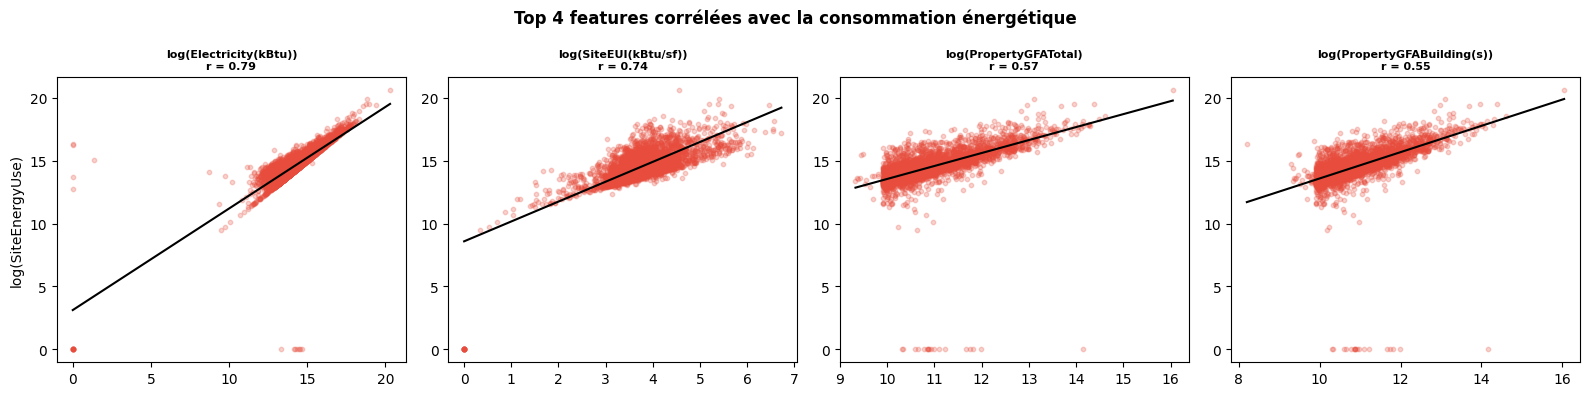

In [ ]:
top_corr_features = (
    corr['SiteEnergyUse(kBtu)']
    .drop(TARGETS)
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top_corr_features):
    x = np.log1p(df_labeled[feat].clip(lower=0))
    y = np.log1p(df_labeled['SiteEnergyUse(kBtu)'])
    axes[i].scatter(x, y, alpha=0.25, s=10, color='#e74c3c')
    # Ligne de tendance
    m, b = np.polyfit(x.dropna(), y[x.notna()], 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='black', linewidth=1.5)
    r = corr.loc[feat, 'SiteEnergyUse(kBtu)']
    axes[i].set_title(f'log({feat})\nr = {r:.2f}', fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('log(SiteEnergyUse)' if i == 0 else '')
plt.suptitle('Top 4 features corrélées avec la consommation énergétique', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-776284149.py:14: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


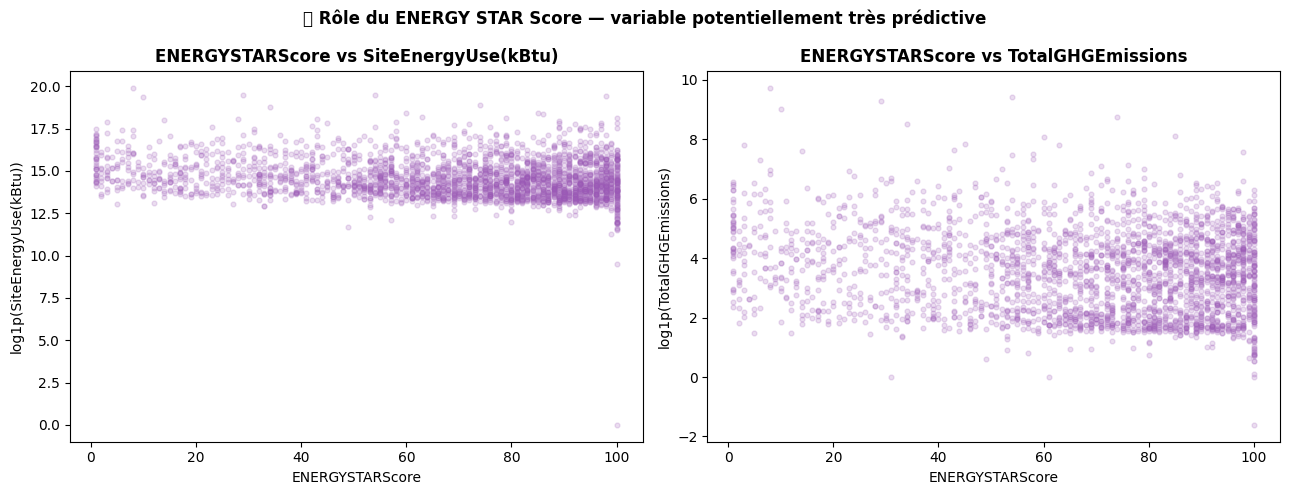

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, target in enumerate(TARGETS):
    data = df_labeled.dropna(subset=['ENERGYSTARScore', target])
    axes[i].scatter(data['ENERGYSTARScore'],
                    np.log1p(data[target]),
                    alpha=0.2, s=12, color='#9b59b6')
    axes[i].set_xlabel('ENERGYSTARScore')
    axes[i].set_ylabel(f'log1p({target})')
    axes[i].set_title(f'ENERGYSTARScore vs {target}', fontweight='bold')

plt.suptitle('⭐ Rôle du ENERGY STAR Score — variable potentiellement très prédictive',
             fontweight='bold')
plt.tight_layout()
plt.show()

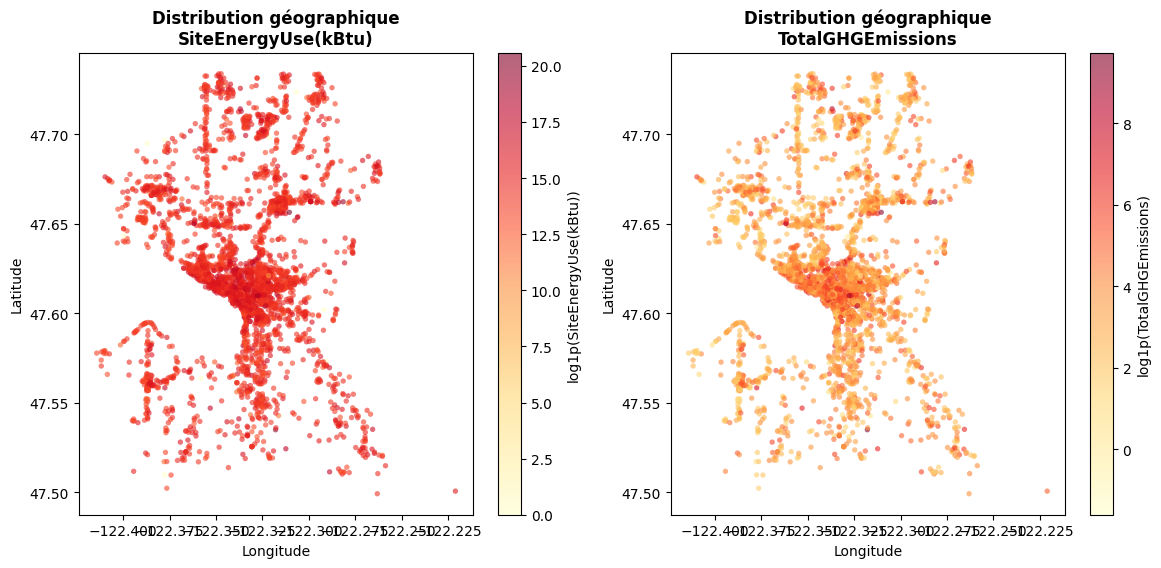

In [ ]:
df_geo = df_labeled.dropna(subset=['Latitude', 'Longitude', 'SiteEnergyUse(kBtu)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, target in enumerate(TARGETS):
    df_t = df_labeled.dropna(subset=['Latitude', 'Longitude', target])
    sc = axes[i].scatter(
        df_t['Longitude'], df_t['Latitude'],
        c=np.log1p(df_t[target]),
        cmap='YlOrRd', alpha=0.6, s=15, edgecolors='none'
    )
    plt.colorbar(sc, ax=axes[i], label=f'log1p({target})')
    axes[i].set_title(f'Distribution géographique\n{target}', fontweight='bold')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')

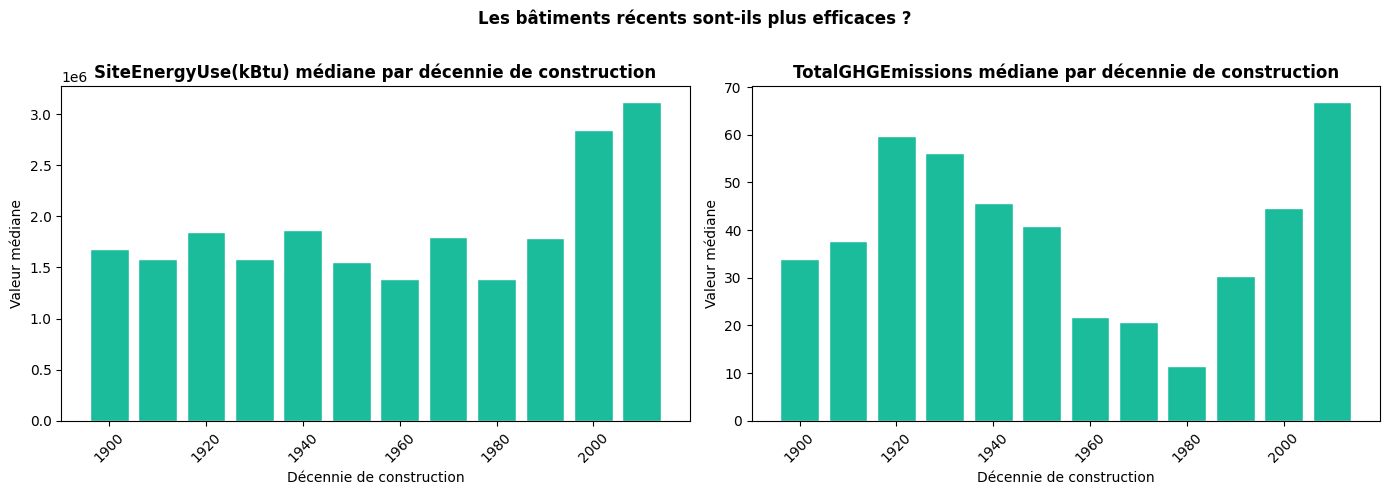

In [ ]:
df_year = df_labeled[(df_labeled['YearBuilt'] >= 1900) & (df_labeled['YearBuilt'] <= 2016)].copy()
df_year['decade'] = (df_year['YearBuilt'] // 10 * 10).astype(int)

median_by_decade = df_year.groupby('decade')[TARGETS].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(TARGETS):
    axes[i].bar(median_by_decade['decade'],
                median_by_decade[target],
                width=8, color='#1abc9c', edgecolor='white')
    axes[i].set_title(f'{target} médiane par décennie de construction', fontweight='bold')
    axes[i].set_xlabel('Décennie de construction')
    axes[i].set_ylabel('Valeur médiane')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Les bâtiments récents sont-ils plus efficaces ?', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
COLS_TO_DROP = [
    'OSEBuildingID',           # identifiant
    'DataYear',                # toujours 2016
    'PropertyName',            # texte libre
    'Address', 'City', 'State', 'ZipCode',  # redondant avec Lat/Long
    'TaxParcelIdentificationNumber',
    'Comments',                # texte libre
    'ComplianceStatus',        # administratif
    'DefaultData',             # flag technique
    'Outlier',                 # flag post-hoc
    'ListOfAllPropertyUseTypes',  # texte composite
    'YearsENERGYSTARCertified',   # > 80% manquant
    'SecondLargestPropertyUseType',   # > 60% manquant
    'ThirdLargestPropertyUseType',    # > 80% manquant
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseTypeGFA',
    # Redondances avec SiteEnergyUse (weather-normalized = version corrigée, on garde)
    'SiteEUI(kBtu/sf)',        # = SiteEnergyUse / surface → leakage potentiel
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',   # version weather-normalized → très corrélée à la cible
    'GHGEmissionsIntensity',   # = TotalGHGEmissions / surface → leakage
    'Electricity(kWh)',        # doublon de Electricity(kBtu)
    'NaturalGas(therms)', # doublon de NaturalGas(kBtu)
    'CouncilDistrictCode'
]

# Ne supprimer que les colonnes qui existent réellement
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df_labeled.columns] # Modified to use df_labeled.columns

df_clean = df_labeled.drop(columns=COLS_TO_DROP) # Modified to use df_labeled
print(f' Colonnes supprimées : {len(COLS_TO_DROP)}')
print(f'   Dataset restant : {df_clean.shape[1]} colonnes\n')
print('Colonnes conservées :', df_clean.columns.tolist())

✅ Colonnes supprimées : 26
   Dataset restant : 20 colonnes

Colonnes conservées : ['BuildingType', 'PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions']


In [ ]:
df_fe = df_clean.copy()

# ── 1. Âge du bâtiment ──────────────────────────────────────────────────────
df_fe['age_batiment'] = 2016 - df_fe['YearBuilt']
df_fe['age_batiment'] = df_fe['age_batiment'].clip(lower=0)  # pas d'âge négatif

# ── 2. Ratio parking ────────────────────────────────────────────────────────
# Part de la surface totale dédiée au parking
df_fe['ratio_parking'] = (
    df_fe['PropertyGFAParking'] / df_fe['PropertyGFATotal'].replace(0, np.nan)
)

# ── 3. Part de chaque source d'énergie ──────────────────────────────────────
# ⚠️ On utilise les valeurs brutes SANS diviser par SiteEnergyUse (cible)
#    pour éviter toute fuite de données
total_energy_proxy = (
    df_fe['Electricity(kBtu)'].fillna(0) +
    df_fe['NaturalGas(kBtu)'].fillna(0) +
    df_fe['SteamUse(kBtu)'].fillna(0)
)

df_fe['prop_electricite'] = (
    df_fe['Electricity(kBtu)'].fillna(0) / total_energy_proxy.replace(0, np.nan)
)
df_fe['prop_gaz'] = (
    df_fe['NaturalGas(kBtu)'].fillna(0) / total_energy_proxy.replace(0, np.nan)
)
df_fe['prop_vapeur'] = (
    df_fe['SteamUse(kBtu)'].fillna(0) / total_energy_proxy.replace(0, np.nan)
)

# ── 4. Bâtiment certifié ENERGY STAR (binaire) ──────────────────────────────
df_fe['a_energy_star'] = df_fe['ENERGYSTARScore'].notna().astype(int)

# ── 5. Surface par étage ────────────────────────────────────────────────────
df_fe['surface_par_etage'] = (
    df_fe['PropertyGFABuilding(s)'] /
    df_fe['NumberofFloors'].replace(0, np.nan)
)

print('✅ Nouvelles features créées :')
new_features = ['age_batiment', 'ratio_parking', 'prop_electricite',
                'prop_gaz', 'prop_vapeur', 'a_energy_star', 'surface_par_etage']
print(df_fe[new_features].describe().T[['mean','std','min','max']].round(3))

✅ Nouvelles features créées :
                        mean        std      min          max
age_batiment          47.426     33.101    1.000      116.000
ratio_parking          0.041      0.115    0.000        0.895
prop_electricite       0.733      0.272    0.000        1.000
prop_gaz               0.255      0.271    0.000        1.000
prop_vapeur            0.013      0.073    0.000        0.842
a_energy_star          0.752      0.432    0.000        1.000
surface_par_etage  22387.842  35445.903  221.697  1100000.000


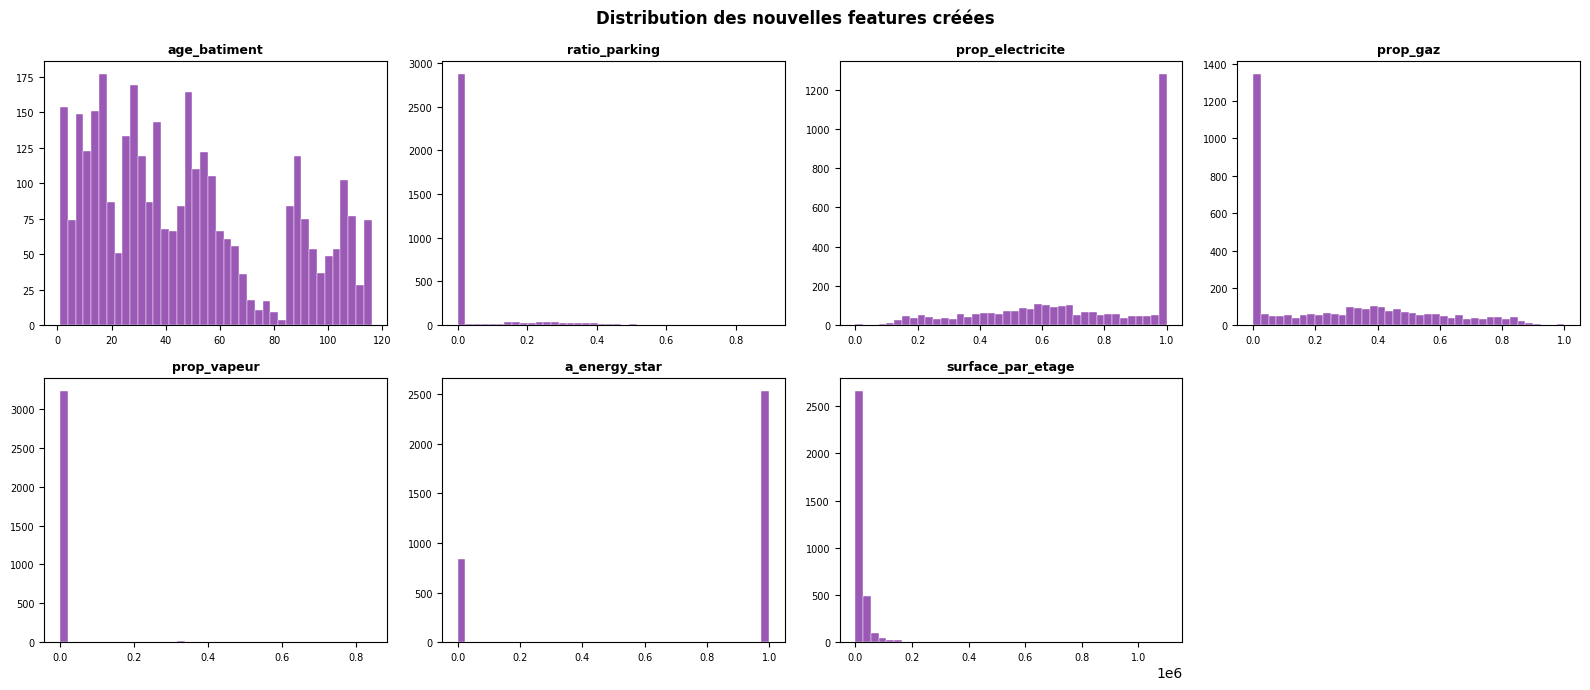

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    data = df_fe[feat].dropna()
    axes[i].hist(data, bins=40, color='#9b59b6', edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribution des nouvelles features créées', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_energy = np.log1p(df_fe['SiteEnergyUse(kBtu)'])
y_co2    = np.log1p(df_fe['TotalGHGEmissions'])

X = df_fe.drop(columns=TARGETS)

print(f'X shape : {X.shape}')
print(f'y_energy shape : {y_energy.shape}')
print(f'y_co2 shape    : {y_co2.shape}')

X shape : (3367, 25)
y_energy shape : (3367,)
y_co2 shape    : (3367,)


In [ ]:
# Train / Test split — 80% / 20%, reproductible
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_energy_train, y_energy_test = train_test_split(
    X, y_energy, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Même split pour CO2 (mêmes indices)
y_co2_train = y_co2.loc[X_train.index]
y_co2_test  = y_co2.loc[X_test.index]

print(f'✅ Train : {X_train.shape[0]:,} lignes ({100*(1-TEST_SIZE):.0f}%)')
print(f'   Test  : {X_test.shape[0]:,} lignes ({100*TEST_SIZE:.0f}%)')

✅ Train : 2,693 lignes (80%)
   Test  : 674 lignes (20%)


In [ ]:
CAT_COLS = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
NUM_COLS = X_train.select_dtypes(include=['number']).columns.tolist()

print(f'Features numériques ({len(NUM_COLS)}) :', NUM_COLS)
print(f'\nFeatures catégorielles ({len(CAT_COLS)}) :', CAT_COLS)

Features numériques (21) : ['CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'age_batiment', 'ratio_parking', 'prop_electricite', 'prop_gaz', 'prop_vapeur', 'a_energy_star', 'surface_par_etage']

Features catégorielles (4) : ['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'LargestPropertyUseType']


In [ ]:
# ── Pipeline numérique ──────────────────────────────────────────────────────
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # remplace NaN par la médiane
    ('scaler',  StandardScaler()),                   # centrage / réduction
])

# ── Pipeline catégoriel ─────────────────────────────────────────────────────
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # remplace NaN par le mode
    ('encoder', OneHotEncoder(handle_unknown='ignore',     # ignore les catégories inconnues
                              sparse_output=False)),
])

# ── ColumnTransformer : applique chaque pipeline aux bonnes colonnes ─────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,    NUM_COLS),
    ('cat', categorical_pipeline, CAT_COLS),
], remainder='drop')  # on ignore les colonnes non listées

print('✅ Preprocessor construit')
print(preprocessor)

✅ Preprocessor construit
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CouncilDistrictCode', 'Latitude',
                                  'Longitude', 'YearBuilt', 'NumberofBuildings',
                                  'NumberofFloors', 'PropertyGFATotal',
                                  'PropertyGFAParking',
                                  'PropertyGFABuilding(s)',
                                  'LargestPropertyUseTypeGFA',
                                  'ENERGYSTARScore', 'SteamUse(kBtu)',
                                  'Electricity(kBtu)', 'NaturalGas(kBtu)',
                                  'age_batiment', 'ratio_parking',
                                  'prop_electricite', 'prop_gaz', 'prop_vapeur',
             

In [ ]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'✅ X_train transformé : {X_train_processed.shape}')
print(f'   X_test transformé  : {X_test_processed.shape}')
print(f'\n   Nombre total de features après encodage : {X_train_processed.shape[1]}')

✅ X_train transformé : (2693, 124)
   X_test transformé  : (674, 124)

   Nombre total de features après encodage : 124


NaN restants — train : 0 | test : 0


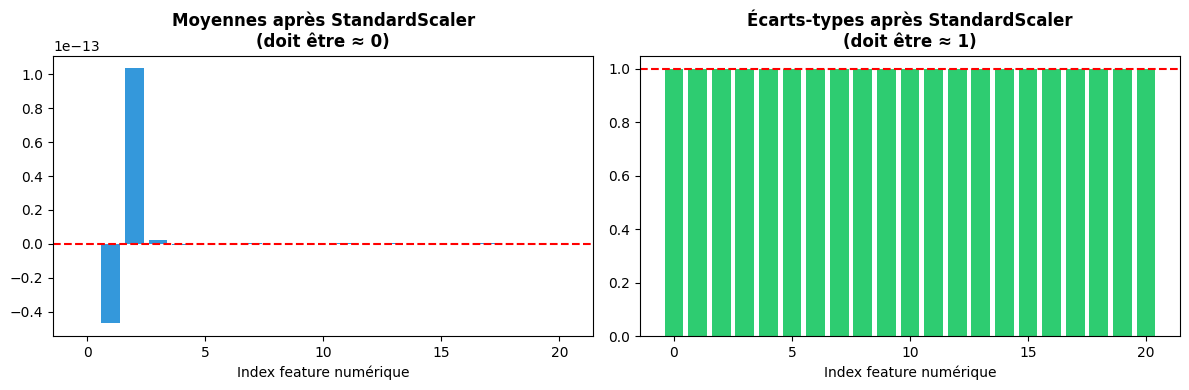

✅ Preprocessing validé !


In [ ]:
# Vérifier qu'il ne reste plus de NaN
nan_train = np.isnan(X_train_processed).sum()
nan_test  = np.isnan(X_test_processed).sum()
print(f'NaN restants — train : {nan_train} | test : {nan_test}')

# Vérifier la distribution après normalisation (features numériques)
num_features_processed = X_train_processed[:, :len(NUM_COLS)]
means = num_features_processed.mean(axis=0)
stds  = num_features_processed.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(means)), means, color='#3498db')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Moyennes après StandardScaler\n(doit être ≈ 0)', fontweight='bold')
axes[0].set_xlabel('Index feature numérique')

axes[1].bar(range(len(stds)), stds, color='#2ecc71')
axes[1].axhline(1, color='red', linestyle='--')
axes[1].set_title('Écarts-types après StandardScaler\n(doit être ≈ 1)', fontweight='bold')
axes[1].set_xlabel('Index feature numérique')

plt.tight_layout()
plt.show()
print('✅ Preprocessing validé !')

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='', cv=5):
    """
    Entraîne un modèle et retourne un dict de métriques.
    Les cibles sont en log1p → on calcule les métriques dans l'espace log ET l'espace original.
    """
    start = time.time()

    # Validation croisée sur le train set
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    cv_rmse = -cross_val_score(model, X_train, y_train,
                               scoring='neg_root_mean_squared_error',
                               cv=kf, n_jobs=-1)
    cv_r2   =  cross_val_score(model, X_train, y_train,
                               scoring='r2',
                               cv=kf, n_jobs=-1)

    # Entraînement final sur tout le train set
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    # Prédictions sur le test set (espace log)
    y_pred_log = model.predict(X_test)

    # Retour dans l'espace original pour des métriques interprétables
    y_pred_orig = np.expm1(y_pred_log)
    y_true_orig = np.expm1(y_test)

    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2_test   = r2_score(y_test, y_pred_log)

    return {
        'Modèle'         : model_name,
        'CV RMSE (log)'  : round(cv_rmse.mean(), 4),
        'CV RMSE std'    : round(cv_rmse.std(), 4),
        'CV R²'          : round(cv_r2.mean(), 4),
        'Test R²'        : round(r2_test, 4),
        'Test MAE (orig)': round(mae_orig, 0),
        'Test RMSE (orig)': round(rmse_orig, 0),
        'Temps (s)'      : round(elapsed, 2),
        '_model'         : model,
        '_y_pred_log'    : y_pred_log,
    }


def plot_comparison(results_df, title):
    """Graphique comparatif des modèles."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    colors = sns.color_palette('viridis', len(results_df))

    # CV R²
    bars = axes[0].barh(results_df['Modèle'], results_df['CV R²'], color=colors)
    axes[0].set_title('CV R² (plus haut = meilleur)', fontweight='bold')
    axes[0].set_xlim(0, 1)
    axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

    # CV RMSE (log)
    bars2 = axes[1].barh(results_df['Modèle'], results_df['CV RMSE (log)'], color=colors)
    axes[1].set_title('CV RMSE log (plus bas = meilleur)', fontweight='bold')
    axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

    # Test R²
    bars3 = axes[2].barh(results_df['Modèle'], results_df['Test R²'], color=colors)
    axes[2].set_title('Test R² (plus haut = meilleur)', fontweight='bold')
    axes[2].set_xlim(0, 1)
    axes[2].bar_label(bars3, fmt='%.3f', padding=3, fontsize=8)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_predicted_vs_actual(y_true_log, y_pred_log, model_name, target_name):
    """Scatter plot Predicted vs Actual + distribution des résidus."""
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    residuals   = y_true_log - y_pred_log

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Predicted vs Actual
    axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.3, s=12, color='#e74c3c')
    lim = max(y_true_orig.max(), y_pred_orig.max()) * 1.05
    axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Prédiction parfaite')
    axes[0].set_xlabel('Valeurs réelles')
    axes[0].set_ylabel('Valeurs prédites')
    axes[0].set_title(f'{model_name}\nPredicted vs Actual — {target_name}', fontweight='bold')
    axes[0].legend(fontsize=8)

    # Distribution des résidus
    sns.histplot(residuals, kde=True, ax=axes[1], color='#3498db', bins=40)
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_xlabel('Résidu (log scale)')
    axes[1].set_title(f'Distribution des résidus\nmoyenne = {residuals.mean():.3f}', fontweight='bold')

    plt.tight_layout()
    plt.show()


print('✅ Fonctions utilitaires chargées')

✅ Fonctions utilitaires chargées


In [ ]:
MODELS = {
    # ── Baselines ──────────────────────────────────────────────────
    'LinearRegression' : LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),

    # ── Arbres ─────────────────────────────────────────────────────
    'DecisionTree'     : DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'RandomForest'     : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                                               n_jobs=-1),

    # ── Gradient Boosting ─────────────────────────────────────────
    'GradientBoosting' : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                   max_depth=5, random_state=RANDOM_STATE),
    'XGBoost'          : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=6, subsample=0.8,
                                      colsample_bytree=0.8,
                                      random_state=RANDOM_STATE,
                                      verbosity=0, n_jobs=-1),
    'LightGBM'         : LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=6, subsample=0.8,
                                       colsample_bytree=0.8,
                                       random_state=RANDOM_STATE,
                                       verbose=-1, n_jobs=-1),
}

print(f'✅ {len(MODELS)} modèles prêts à être testés :')
for name in MODELS:
    print(f'   • {name}')

✅ 7 modèles prêts à être testés :
   • LinearRegression
   • Ridge
   • DecisionTree
   • RandomForest
   • GradientBoosting
   • XGBoost
   • LightGBM


In [ ]:
import time
print('🔄 Entraînement en cours pour SiteEnergyUse...\n')
results_energy = []

for name, model in MODELS.items():
    print(f'   ▶ {name}...', end=' ')
    res = evaluate_model(
        model, X_train_processed, y_energy_train,
        X_test_processed,  y_energy_test,
        model_name=name
    )
    results_energy.append(res)
    print(f'CV R²={res["CV R²"]:.3f} | Test R²={res["Test R²"]:.3f} | {res["Temps (s)"]}s')

print('\n✅ Terminé !')

🔄 Entraînement en cours pour SiteEnergyUse...

   ▶ LinearRegression... CV R²=0.498 | Test R²=-1.097 | 3.78s
   ▶ Ridge... CV R²=0.352 | Test R²=-0.546 | 0.28s
   ▶ DecisionTree... CV R²=0.695 | Test R²=0.842 | 0.74s
   ▶ RandomForest... CV R²=0.770 | Test R²=0.970 | 90.98s
   ▶ GradientBoosting... CV R²=0.736 | Test R²=0.987 | 56.15s
   ▶ XGBoost... CV R²=0.767 | Test R²=0.978 | 12.61s
   ▶ LightGBM... CV R²=0.787 | Test R²=0.893 | 11.27s

✅ Terminé !


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Tableau comparatif
display_cols = ['Modèle', 'CV R²', 'CV RMSE (log)', 'CV RMSE std', 'Test R²',
                'Test MAE (orig)', 'Test RMSE (orig)', 'Temps (s)']

df_energy = pd.DataFrame(results_energy)[display_cols].sort_values('CV R²', ascending=False)
df_energy.style.background_gradient(cmap='Greens', subset=['CV R²', 'Test R²']) \
               .background_gradient(cmap='Reds_r', subset=['CV RMSE (log)', 'CV RMSE std'])

,Modèle,CV R²,CV RMSE (log),CV RMSE std,Test R²,Test MAE (orig),Test RMSE (orig),Temps (s)
6,LightGBM,0.787100,0.714900,0.082300,0.893400,2353787.000000,33050836.000000,11.270000
3,RandomForest,0.769600,0.729500,0.139300,0.970400,1520800.000000,26434903.000000,90.980000
5,XGBoost,0.767500,0.735100,0.128800,0.977500,1824878.000000,30692109.000000,12.610000
4,GradientBoosting,0.735500,0.784400,0.164500,0.987100,1310802.000000,23249794.000000,56.150000
2,DecisionTree,0.694600,0.844400,0.164400,0.842000,1735319.000000,27490597.000000,0.740000
0,LinearRegression,0.498100,1.098500,0.153700,-1.097200,15204184962431848306121375744.000000,394723599510618764745036005376.000000,3.780000
1,Ridge,0.352400,1.250200,0.192000,-0.546100,1898125129222223720087552.000000,49278194469446744040013824.000000,0.280000


In [ ]:
# Réinitialiser les modèles (pour avoir des instances fraîches)
MODELS_CO2 = {
    'LinearRegression' : LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'DecisionTree'     : DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'RandomForest'     : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting' : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                   max_depth=5, random_state=RANDOM_STATE),
    'XGBoost'          : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=6, subsample=0.8, colsample_bytree=0.8,
                                      random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    'LightGBM'         : LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=6, subsample=0.8, colsample_bytree=0.8,
                                       random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
}

print('🔄 Entraînement en cours pour TotalGHGEmissions...\n')
results_co2 = []

for name, model in MODELS_CO2.items():
    print(f'   ▶ {name}...', end=' ')
    res = evaluate_model(
        model, X_train_processed, y_co2_train,
        X_test_processed,  y_co2_test,
        model_name=name
    )
    results_co2.append(res)
    print(f'CV R²={res["CV R²"]:.3f} | Test R²={res["Test R²"]:.3f} | {res["Temps (s)"]}s')

print('\n✅ Terminé !')

🔄 Entraînement en cours pour TotalGHGEmissions...

   ▶ LinearRegression... CV R²=0.755 | Test R²=-0.908 | 0.52s
   ▶ Ridge... CV R²=0.724 | Test R²=-0.319 | 0.27s
   ▶ DecisionTree... CV R²=0.981 | Test R²=0.977 | 0.71s
   ▶ RandomForest... CV R²=0.991 | Test R²=0.991 | 83.95s
   ▶ GradientBoosting... CV R²=0.994 | Test R²=0.996 | 53.79s
   ▶ XGBoost... CV R²=0.995 | Test R²=0.995 | 12.96s
   ▶ LightGBM... CV R²=0.993 | Test R²=0.991 | 8.15s

✅ Terminé !


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Tableau comparatif pour TotalGHGEmissions
display_cols = ['Modèle', 'CV R²', 'CV RMSE (log)', 'CV RMSE std', 'Test R²',
                'Test MAE (orig)', 'Test RMSE (orig)', 'Temps (s)']

df_co2 = pd.DataFrame(results_co2)[display_cols].sort_values('CV R²', ascending=False)
df_co2.style.background_gradient(cmap='Greens', subset=['CV R²', 'Test R²']) \
               .background_gradient(cmap='Reds_r', subset=['CV RMSE (log)', 'CV RMSE std'])

,Modèle,CV R²,CV RMSE (log),CV RMSE std,Test R²,Test MAE (orig),Test RMSE (orig),Temps (s)
5,XGBoost,0.995100,0.097800,0.025100,0.994800,39.000000,483.000000,12.960000
4,GradientBoosting,0.993800,0.108100,0.037200,0.996400,34.000000,412.000000,53.790000
6,LightGBM,0.992700,0.120700,0.025400,0.991100,45.000000,538.000000,8.150000
3,RandomForest,0.991200,0.131400,0.032700,0.990800,40.000000,533.000000,83.950000
2,DecisionTree,0.981000,0.193600,0.037100,0.976500,63.000000,657.000000,0.710000
0,LinearRegression,0.754700,0.695900,0.129600,-0.908300,6486635276962746073088.000000,168402846424315254013952.000000,0.520000
1,Ridge,0.723900,0.736800,0.148700,-0.318500,5843327541908339712.000000,151701606245960876032.000000,0.270000


/tmp/ipython-input-2813127952.py:70: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


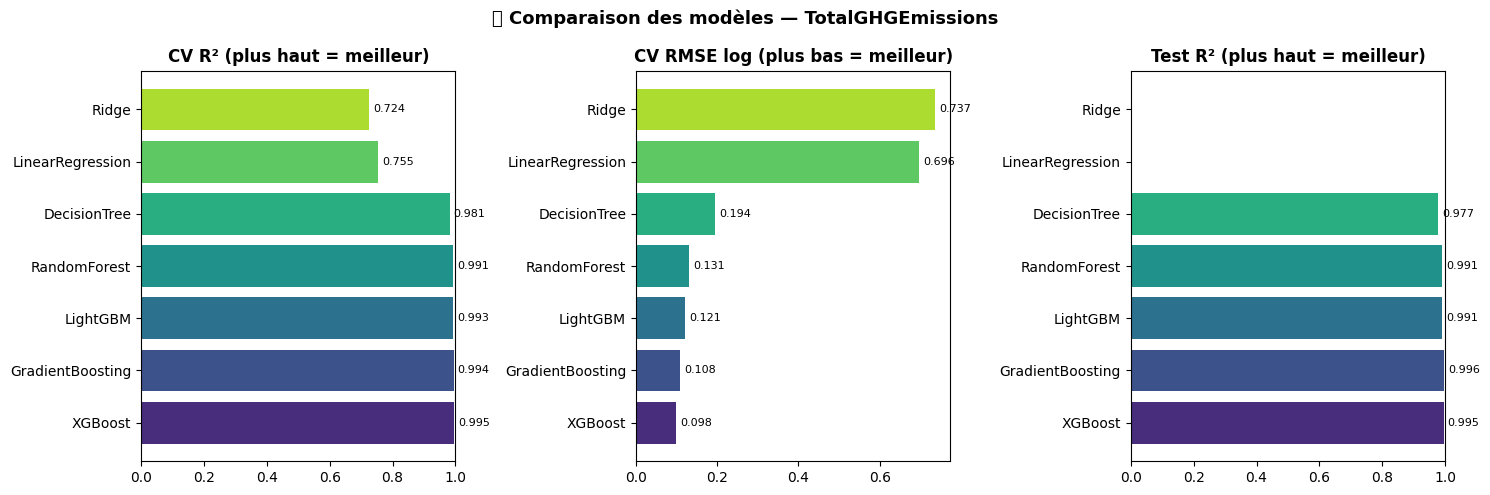

In [ ]:
plot_comparison(df_co2, '📊 Comparaison des modèles — TotalGHGEmissions')

In [ ]:
# Sélection automatique du meilleur modèle (CV R²)
best_energy_name = df_energy.iloc[0]['Modèle']
best_co2_name    = df_co2.iloc[0]['Modèle']

best_energy = next(r for r in results_energy if r['Modèle'] == best_energy_name)
best_co2    = next(r for r in results_co2    if r['Modèle'] == best_co2_name)

print(f'🏆 Meilleur modèle — Énergie : {best_energy_name}')
print(f'   CV R² = {best_energy["CV R²"]} | Test R² = {best_energy["Test R²"]}')
print(f'\n🏆 Meilleur modèle — CO₂    : {best_co2_name}')
print(f'   CV R² = {best_co2["CV R²"]} | Test R² = {best_co2["Test R²"]}')

🏆 Meilleur modèle — Énergie : LightGBM
   CV R² = 0.7871 | Test R² = 0.8934

🏆 Meilleur modèle — CO₂    : XGBoost
   CV R² = 0.9951 | Test R² = 0.9948


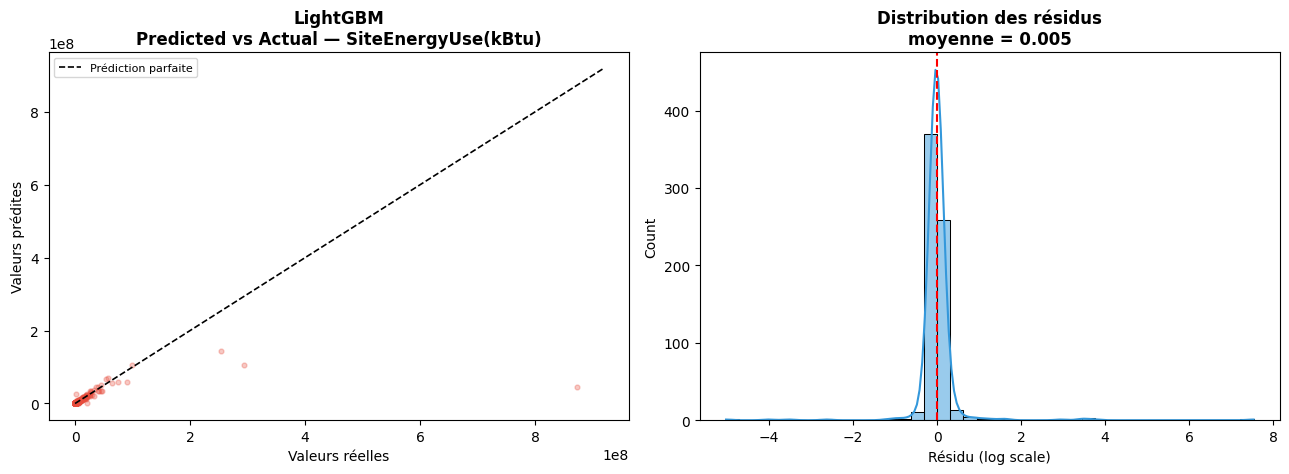

In [ ]:
# Predicted vs Actual — Énergie
plot_predicted_vs_actual(
    y_energy_test.values,
    best_energy['_y_pred_log'],
    best_energy_name,
    'SiteEnergyUse(kBtu)'
)

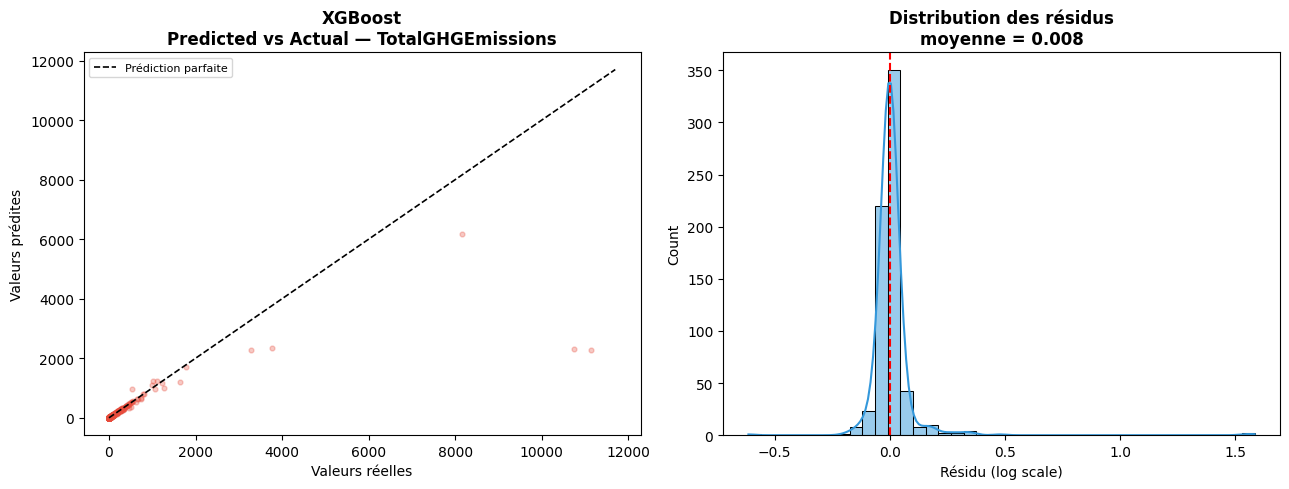

In [ ]:
# Predicted vs Actual — CO₂
plot_predicted_vs_actual(
    y_co2_test.values,
    best_co2['_y_pred_log'],
    best_co2_name,
    'TotalGHGEmissions'
)

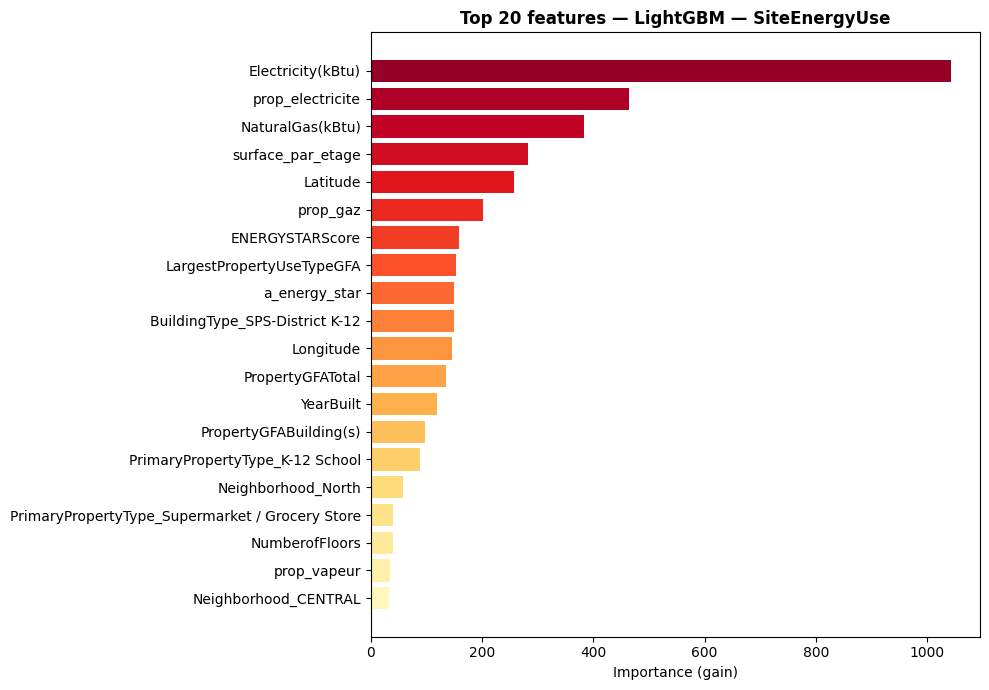

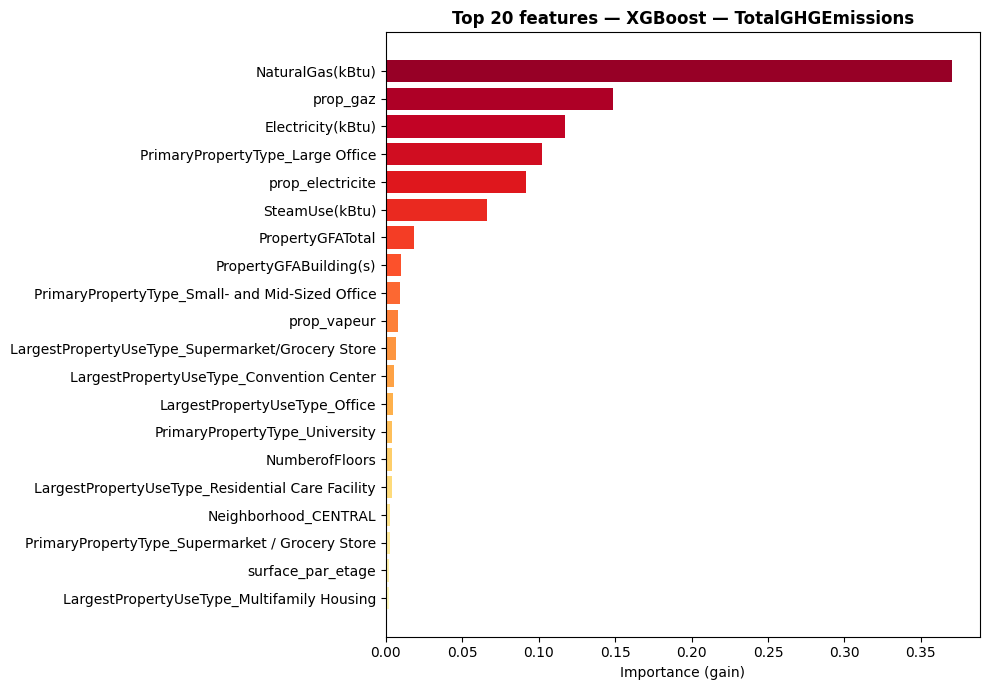

In [ ]:
def plot_feature_importance(model, feature_names, title, top_n=20):
    """Affiche les top N features les plus importantes."""
    if not hasattr(model, 'feature_importances_'):
        print(f'⚠️ {title} — ce modèle ne fournit pas de feature_importances_')
        return

    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top.index, top.values,
                   color=sns.color_palette('YlOrRd', top_n))
    ax.set_title(f'Top {top_n} features — {title}', fontweight='bold')
    ax.set_xlabel('Importance (gain)')
    plt.tight_layout()
    plt.show()

ohe_feature_names = (
    preprocessor
    .named_transformers_['cat']['encoder']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
all_feature_names = NUM_COLS + ohe_feature_names

plot_feature_importance(
    best_energy['_model'], all_feature_names,
    f'{best_energy_name} — SiteEnergyUse'
)

plot_feature_importance(
    best_co2['_model'], all_feature_names,
    f'{best_co2_name} — TotalGHGEmissions'
)

In [ ]:
# Colonnes liées à ENERGY STAR (dans les features d'entrée X)
energy_star_cols_names = [c for c in X.columns
                          if 'ENERGYSTAR' in c.upper() or 'energy_star' in c.lower()]
print('Colonnes ENERGY STAR (dans X) :', energy_star_cols_names)

if energy_star_cols_names:
    # 1. Identifier les indices des colonnes ENERGY STAR dans le tableau traité
    # 'all_feature_names' contient l'ordre des colonnes après préprocessing.
    # Il est important que cette liste soit correcte et à jour.
    ohe_feature_names = (
        preprocessor
        .named_transformers_['cat']['encoder']
        .get_feature_names_out(CAT_COLS)
        .tolist()
    )
    all_feature_names_processed = NUM_COLS + ohe_feature_names

    # Obtenir les indices des colonnes à supprimer dans le tableau numpy traité
    es_indices = [all_feature_names_processed.index(col) for col in energy_star_cols_names if col in all_feature_names_processed]

    # 2. Créer des copies des données traitées et supprimer les colonnes ENERGY STAR
    X_train_processed_no_es = np.delete(X_train_processed, es_indices, axis=1)
    X_test_processed_no_es  = np.delete(X_test_processed, es_indices, axis=1)

    print(f'Shape de X_train_processed_no_es: {X_train_processed_no_es.shape}')
    print(f'Shape de X_test_processed_no_es: {X_test_processed_no_es.shape}')

    best_model_class = type(best_energy['_model'])
    # Assurez-vous d'obtenir une nouvelle instance du modèle pour éviter les interférences
    model_no_es = best_model_class(**best_energy['_model'].get_params())

    res_no_es = evaluate_model(
        model_no_es, X_train_processed_no_es, y_energy_train,
        X_test_processed_no_es,  y_energy_test,
        model_name='Sans ENERGY STAR'
    )

    print('\n=== Impact du ENERGY STAR Score ===')
    print(f"Avec    ENERGY STAR — CV R²: {best_energy['CV R²']} | Test R²: {best_energy['Test R²']}")
    print(f"Sans    ENERGY STAR — CV R²: {res_no_es['CV R²']} | Test R²: {res_no_es['Test R²']}")
    delta = best_energy['CV R²'] - res_no_es['CV R²']
    print(f"Différence de CV R² : {delta:+.4f}")
    if abs(delta) < 0.005:
        print('→ ⚠️ L\'ENERGY STAR Score a peu d\'impact sur ce modèle.')
    elif delta > 0:
        print("→ ✅ L'ENERGY STAR Score améliore les prédictions.")
    else:
        print("→ ⚠️ L'ENERGY STAR Score dégrade les prédictions (peut-être du bruit).")
else:
    print('⚠️ Aucune colonne ENERGY STAR trouvée dans X_train.')

Colonnes ENERGY STAR (dans X) : ['ENERGYSTARScore', 'a_energy_star']
Shape de X_train_processed_no_es: (2693, 122)
Shape de X_test_processed_no_es: (674, 122)

=== Impact du ENERGY STAR Score ===
Avec    ENERGY STAR — CV R²: 0.7871 | Test R²: 0.8934
Sans    ENERGY STAR — CV R²: 0.7303 | Test R²: 0.8046
Différence de CV R² : +0.0568
→ ✅ L'ENERGY STAR Score améliore les prédictions.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Grille de recherche pour LightGBM
param_distributions = {
    'n_estimators':      [200, 300, 400, 500],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'max_depth':         [4, 6, 8, 10, -1],  # -1 = pas de limite
    'num_leaves':        [20, 31, 50, 70],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha':         [0.0, 0.01, 0.1],  # L1 regularization
    'reg_lambda':        [0.0, 0.01, 0.1],  # L2 regularization
}

# Modèle de base
lgbm = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)

# RandomizedSearchCV — 50 combinaisons aléatoires
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_distributions,
    n_iter=50,              # nombre de combinaisons à tester
    cv=5,                   # validation croisée 5-fold
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

print('🔄 Lancement de l\'optimisation des hyperparamètres...')
print('   (cela peut prendre 5–15 minutes selon la puissance de ta machine)\n')

start = time.time()
random_search.fit(X_train_processed, y_energy_train)
elapsed = time.time() - start

print(f'\n✅ Optimisation terminée en {elapsed/60:.1f} minutes')
print(f'\nMeilleur score (CV R²) : {random_search.best_score_:.4f}')
print(f'Meilleurs hyperparamètres :')
for param, value in random_search.best_params_.items():
    print(f'  • {param}: {value}')

🔄 Lancement de l'optimisation des hyperparamètres...
   (cela peut prendre 5–15 minutes selon la puissance de ta machine)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Optimisation terminée en 7.2 minutes

Meilleur score (CV R²) : 0.8723
Meilleurs hyperparamètres :
  • subsample: 0.9
  • reg_lambda: 0.01
  • reg_alpha: 0.01
  • num_leaves: 50
  • n_estimators: 500
  • min_child_samples: 50
  • max_depth: 8
  • learning_rate: 0.1
  • colsample_bytree: 0.8


In [ ]:
# Récupérer le meilleur modèle
best_lgbm = random_search.best_estimator_

# Évaluation sur le test set
y_pred_log = best_lgbm.predict(X_test_processed)
test_r2 = r2_score(y_energy_test, y_pred_log)

# Retour dans l'espace original
y_pred_orig = np.expm1(y_pred_log)
y_true_orig = np.expm1(y_energy_test)
test_mae  = mean_absolute_error(y_true_orig, y_pred_orig)
test_rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))

print('\n=== Performance du modèle optimisé ===')
print(f'Test R²           : {test_r2:.4f}')
print(f'Test MAE (original) : {test_mae:,.0f} kBtu')
print(f'Test RMSE (original): {test_rmse:,.0f} kBtu')


=== Performance du modèle optimisé ===
Test R²           : 0.9488
Test MAE (original) : 2,641,956 kBtu
Test RMSE (original): 34,043,372 kBtu


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🔄 Calcul des courbes d'apprentissage...


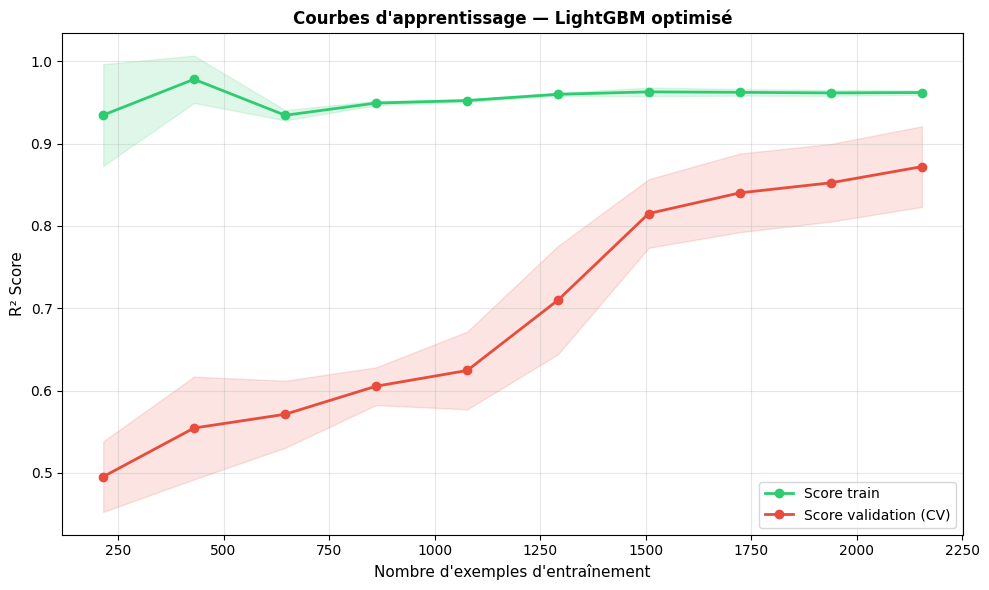


✅ Interprétation :
   Écart train/val final : 0.0900
   → ⚠️ Léger overfitting, mais acceptable
   → ✅ Performance élevée, le modèle est solide


In [ ]:
from sklearn.model_selection import learning_curve

print('🔄 Calcul des courbes d\'apprentissage...')

train_sizes, train_scores, val_scores = learning_curve(
    best_lgbm, X_train_processed, y_energy_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=RANDOM_STATE
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std  = train_scores.std(axis=1)
val_scores_mean   = val_scores.mean(axis=1)
val_scores_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# Courbe train
ax.plot(train_sizes, train_scores_mean, 'o-', color='#2ecc71',
        label='Score train', linewidth=2)
ax.fill_between(train_sizes,
                train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std,
                alpha=0.15, color='#2ecc71')

# Courbe validation
ax.plot(train_sizes, val_scores_mean, 'o-', color='#e74c3c',
        label='Score validation (CV)', linewidth=2)
ax.fill_between(train_sizes,
                val_scores_mean - val_scores_std,
                val_scores_mean + val_scores_std,
                alpha=0.15, color='#e74c3c')

ax.set_xlabel('Nombre d\'exemples d\'entraînement', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Courbes d\'apprentissage — LightGBM optimisé', fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✅ Interprétation :')
gap = train_scores_mean[-1] - val_scores_mean[-1]
print(f'   Écart train/val final : {gap:.4f}')
if gap < 0.05:
    print('   → ✅ Modèle bien généralisé, pas d\'overfitting significatif')
elif gap < 0.15:
    print('   → ⚠️ Léger overfitting, mais acceptable')
else:
    print('   → ⚠️ Overfitting détecté — envisager plus de régularisation')

if val_scores_mean[-1] > 0.85:
    print('   → ✅ Performance élevée, le modèle est solide')
elif val_scores_mean[-1] > 0.7:
    print('   → 🔶 Performance correcte, mais peut être améliorée')
else:
    print('   → ⚠️ Performance faible, revoir le feature engineering')